<a href="https://colab.research.google.com/github/harmanbajwa2954/Machine-Learning-Notebooks/blob/main/Energy_Consumption_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Energy Consumption Prediction

This Project aims to predict the electricity consumption for various types of consumers such as — **Residential**, **Commercial**, **Industrial**.

> Here we will employ the **Random Forest Regressor** model since the *target* is continuous variable.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import pickle

## Importing Dataset

In [ ]:
# Load datasets
train_df = pd.read_csv('https://raw.githubusercontent.com/harmanbajwa2954/datasets/refs/heads/main/Energy%20Consumption/train_energy.csv')
test_df = pd.read_csv('https://raw.githubusercontent.com/harmanbajwa2954/datasets/refs/heads/main/Energy%20Consumption/test_energy_data.csv')

In [ ]:
# Basic Info
print(train_df.info())
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB
None


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


## Exploratory Data Analasys (EDA)

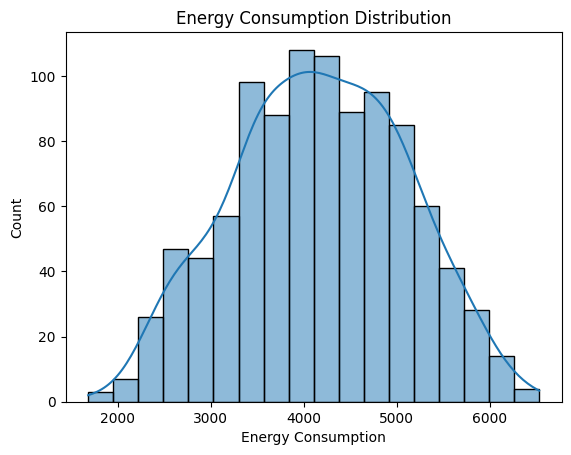

In [ ]:
# 1 Target Distribution
sns.histplot(train_df['Energy Consumption'], kde=True)
plt.title('Energy Consumption Distribution')

plt.show()

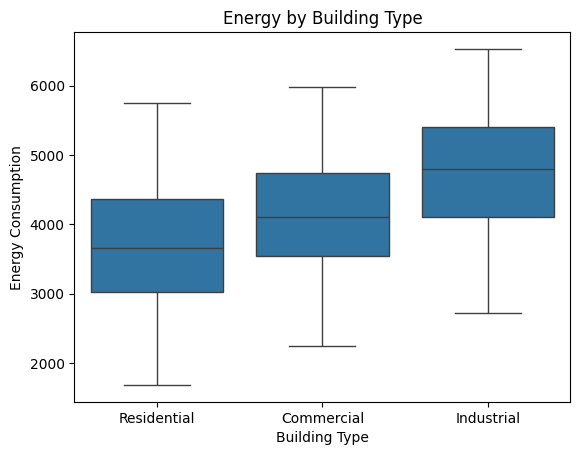

In [ ]:
# 2. Building Type vs Energy
sns.boxplot(x='Building Type', y='Energy Consumption', data=train_df)
plt.title('Energy by Building Type')

plt.show()

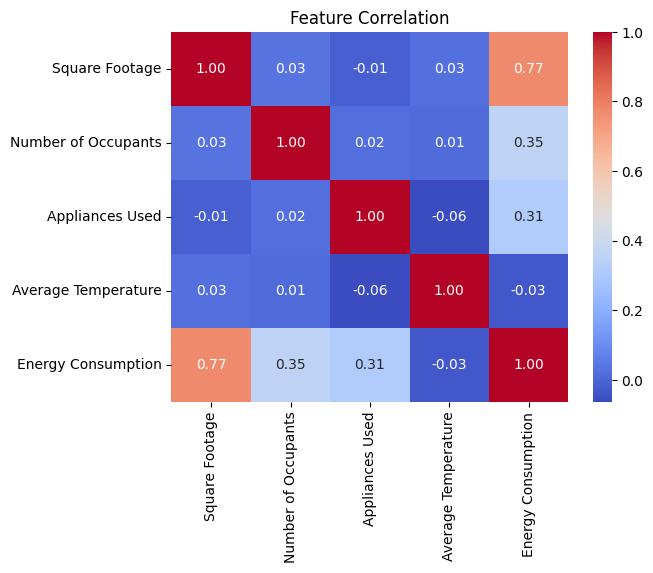

In [ ]:
# 3 Correlation Heatmap (Numerical features)
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation')

plt.show()

## Preprocessing and Pipeline Setup

In [ ]:
# Separate features and target
X_train = train_df.drop('Energy Consumption', axis=1)
y_train = train_df['Energy Consumption']
X_test = test_df.drop('Energy Consumption', axis=1)
y_test = test_df['Energy Consumption']

In [ ]:
# Define column types
categorical_features = ['Building Type', 'Day of Week']
numeric_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']

In [ ]:
# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Create Base Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

## Model Training and Evaluation

In [ ]:
# Train model
pipeline.fit(X_train, y_train)
y_pred_base = pipeline.predict(X_test)

In [ ]:
# Evaluate base model
print("--- Base Model Evaluation ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_base):.4f}")

--- Base Model Evaluation ---
RMSE: 118.40
R2 Score: 0.9796


## HyperParameter Tuning using GridSearchCV

In [ ]:
# Define parameter grid for Random Forest
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

# Perform Grid Search (uses cross-validation)
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [ ]:
# Get the best model
best_model = grid_search.best_estimator_

# Predict on test set
y_pred_best = best_model.predict(X_test)

# Final Evaluation
print("--- Tuned Model Evaluation ---")
print(f"RMSE: {mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_best):.4f}")

--- Tuned Model Evaluation ---
RMSE: 14039.30
R2 Score: 0.9795


### Plot : Actual vs Predicted

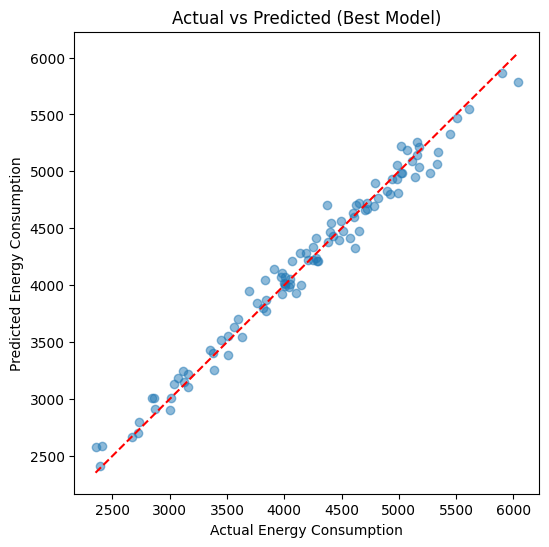

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs Predicted (Best Model)')
plt.show()

## Saving the model

In [ ]:
with open('model.pkl', 'wb') as file:
    pickle.dump(y_pred_base, file)